### Approach A, using Random Forest Regression

##### Our dataset, energydata_complete.csv, is continuous so it is appropiate to start with regression metrics over classification. 



In [2]:
## Load Data, import required libraries, sklearn and matplot
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt

path = "C:\Datasets" 

##Read data file
filename_read = os.path.join(path, "energydata_complete.csv")
data = pd.read_csv(filename_read)

# print(data.head())
print(data.shape)
data.info()

## SET target column, column 'Appliances'
target = "Appliances"

## DROP date column, string
## TARGET from X
X = data.drop(columns=["date", target]).values
y = data[target].values

## Train:Test split ( 25% test size ) + reproducable random state, 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

(19735, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float

In [21]:
# R^2 : 
r2_list = []
mae_list = []
nums = []

rf = RandomForestRegressor(
    n_estimators=1,
    random_state=42,
    n_jobs=-1,
    warm_start=True
)

## Loop over trees 
for i in range(1, 129):
    rf.set_params(n_estimators=i)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    nums.append(i)
    r2_list.append(r2)
    mae_list.append(mae)

## No. of descision trees
print(f"Trees: {i:3d}")
##
print(f"R2: {r2:.4f}")
##
print(f"R2: {mae:.3f}")


Trees: 128
R2: 0.5216
R2: 32.925


#### 1. Measuring mean absolute error, mae. Computes average magnitude of a prediction error; how far a prediction is off the true value. We want this value to be as low as possible.

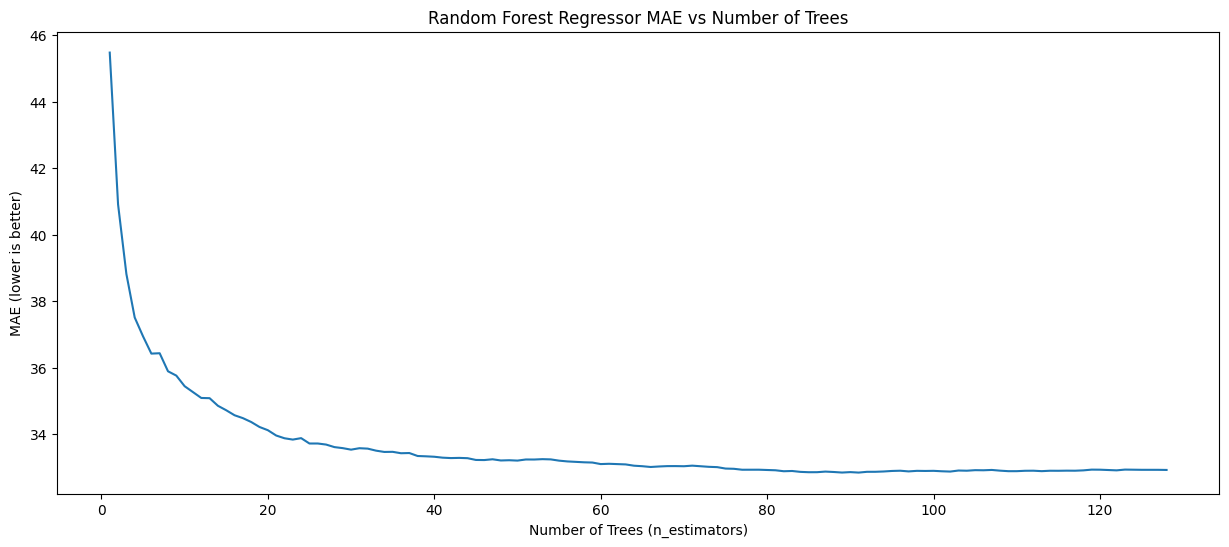

In [23]:
plt.figure(figsize=(15, 6))
plt.plot(nums, mae_list)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("MAE (lower is better)")
plt.title("Random Forest Regressor MAE vs Number of Trees")
plt.show()


##### Observations

#### MAE stagnates around 33, this means around 33 energy units off of the average. This occurs about 35-40 trees are used to build the forest.

### Approach B, converting into classification
#### Testing Accuracy by utilising "Appliance" column as a cateogry, then using values that are above the median or "high-usage".

Trees:   1 | Accuracy: 0.83259
Trees:   2 | Accuracy: 0.83745
Trees:   3 | Accuracy: 0.87110
Trees:   4 | Accuracy: 0.87090
Trees:   5 | Accuracy: 0.87981
Trees:   6 | Accuracy: 0.87900
Trees:   7 | Accuracy: 0.88792
Trees:   8 | Accuracy: 0.88529
Trees:   9 | Accuracy: 0.88974
Trees:  10 | Accuracy: 0.88893
Trees:  11 | Accuracy: 0.89360
Trees:  12 | Accuracy: 0.89177
Trees:  13 | Accuracy: 0.89258
Trees:  14 | Accuracy: 0.89218
Trees:  15 | Accuracy: 0.89664
Trees:  16 | Accuracy: 0.89542
Trees:  17 | Accuracy: 0.89724
Trees:  18 | Accuracy: 0.89582
Trees:  19 | Accuracy: 0.89643
Trees:  20 | Accuracy: 0.89562
Trees:  21 | Accuracy: 0.89582
Trees:  22 | Accuracy: 0.89380
Trees:  23 | Accuracy: 0.89582
Trees:  24 | Accuracy: 0.89522
Trees:  25 | Accuracy: 0.89582
Trees:  26 | Accuracy: 0.89400
Trees:  27 | Accuracy: 0.89481
Trees:  28 | Accuracy: 0.89380
Trees:  29 | Accuracy: 0.89542
Trees:  30 | Accuracy: 0.89562
Trees:  31 | Accuracy: 0.89623
Trees:  32 | Accuracy: 0.89745
Trees:  

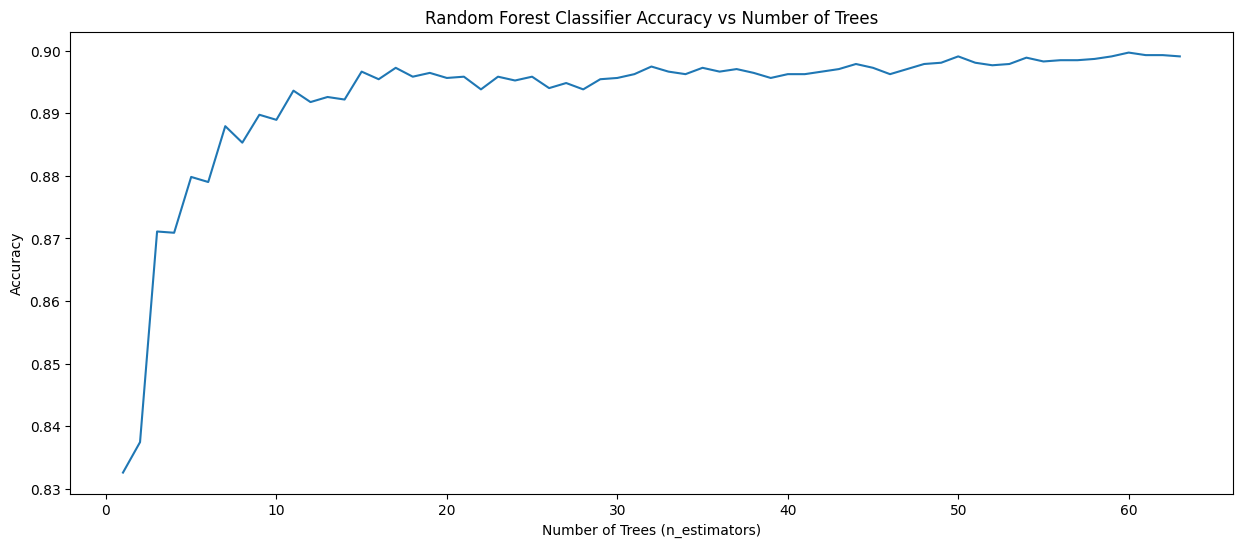

In [4]:
## Load same data, import 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

path = "C:\Datasets" 

##Read data file
filename_read = os.path.join(path, "energydata_complete.csv")
data = pd.read_csv(filename_read)
df = data

# Binary target: 1 if Appliances > median, else 0
median_val = df["Appliances"].median()
df["target"] = (df["Appliances"] > median_val).astype(int)

X = df.drop(columns=["date", "Appliances", "target"]).values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

accuracy_data = []
tree_data = []
nums2 = []


rf2 = RandomForestClassifier(
    n_estimators=1,
    criterion="entropy",
    random_state=42,
    n_jobs=-1,
    # Reuse data that has already been trained
    # Tree 1 trained once, add trees and retain 
    warm_start = True # KEEP UNCOMMENTED 
)

for i in range(1, 64):
    rf2.set_params(n_estimators=i)
    rf2.fit(X_train, y_train)
    y_pred = rf2.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    nums2.append(i)
    accuracy_data.append(acc)

    print(f"Trees: {i:3d} | Accuracy: {acc:.5f}")

plt.figure(figsize=(15, 6))
plt.plot(nums2, accuracy_data)
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Random Forest Classifier Accuracy vs Number of Trees")
plt.show()


### Observations

#### No. of trees used is expotential to the level of accuracy that stagnates at around 40 trees and level the value of accuracy starts to fluctuate between 0.899 and 0.898.